In [1]:
# Optional: install the minimum dependencies needed for SAM-Med3D in this kernel.
# Safe to re-run.

import os
import sys
import subprocess
import importlib.metadata as importlib_metadata

def _version_or_none(pkg_name):
    try:
        return importlib_metadata.version(pkg_name)
    except importlib_metadata.PackageNotFoundError:
        return None

required = [
    "huggingface-hub>=0.23,<1.0",
    "nibabel",
]

missing = []
if _version_or_none("huggingface_hub") is None and _version_or_none("huggingface-hub") is None:
    missing.append("huggingface-hub>=0.23,<1.0")
if _version_or_none("nibabel") is None:
    missing.append("nibabel")

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")


'1'

In [3]:
from pathlib import Path
import os
import sys
import subprocess

import matplotlib.pyplot as plt
import torch
from huggingface_hub import hf_hub_download
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics
from torch.utils.data import DataLoader

# Make local helper modules importable from the notebook directory.
NOTEBOOK_DIR = Path.cwd().parent.parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

from utils.ood_datasets import MRIDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [5]:
from segment_anything import sam_model_registry3D
import torch
from huggingface_hub import hf_hub_download

SAMMED3D_HF_REPO = "blueyo0/SAM-Med3D"
SAMMED3D_CKPT_FILENAME = "sam_med3d_turbo.pth"

def _extract_state_dict_for_sam_med3d(checkpoint_obj):
    if "model_state_dict" in checkpoint_obj:
        return checkpoint_obj["model_state_dict"]
    if "state_dict" in checkpoint_obj:
        return checkpoint_obj["state_dict"]
    if "model" in checkpoint_obj:
        return checkpoint_obj["model"]
    return checkpoint_obj

ckpt_path = hf_hub_download(
    repo_id=SAMMED3D_HF_REPO,
    filename=SAMMED3D_CKPT_FILENAME,
)

# IMPORTANT: use vit_b_ori, not vit_b
sam_med3d = sam_model_registry3D["vit_b_ori"](checkpoint=None)

checkpoint_obj = torch.load(ckpt_path, map_location="cpu")
state_dict = _extract_state_dict_for_sam_med3d(checkpoint_obj)

load_result = sam_med3d.load_state_dict(state_dict, strict=True)
print("Loaded SAM-Med3D from:", ckpt_path)
print(load_result)

sam_med3d = sam_med3d.to(device).eval()

Loaded SAM-Med3D from: /home/jovyan/.cache/huggingface/hub/models--blueyo0--SAM-Med3D/snapshots/fc482a040ea69cdc9ae576a1d6bd9db02ab1994c/sam_med3d_turbo.pth
<All keys matched successfully>


In [6]:
datasets_path = "../datasets/"
prep_datasets = "/prep_datasets"
ID_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Philips"
OOD_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Siemens"

# IMPORTANT:
# SAM-Med3D is a 3D model, so we use MRIDataset in volumetric mode.
# The dataset handles MRI normalization; resize_to_3d matches SAM-Med3D's 256^3 input.
id_train_dataset = MRIDataset(
    root=ID_path,
    output_mode="3d",
    slice_axis=2,
    channels=1,
    resize_to_3d=(128, 128, 128),
    label=0,
    split="train",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
)

id_val_dataset = MRIDataset(
    root=ID_path,
    output_mode="3d",
    slice_axis=2,
    channels=1,
    resize_to_3d=(128, 128, 128),
    label=0,
    split="test",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
)

ood_dataset = MRIDataset(
    root=OOD_path,
    output_mode="3d",
    slice_axis=2,
    channels=1,
    resize_to_3d=(128, 128, 128),
    label=-1,
    split="all",
    seed=42,
    return_metadata=False,
)

# 3D volumes are much heavier than 2D slices; keep the batch size conservative.
id_train_loader = DataLoader(id_train_dataset, batch_size=1, shuffle=True, num_workers=0)
id_val_loader = DataLoader(id_val_dataset, batch_size=1, shuffle=True, num_workers=0)
ood_loader = DataLoader(ood_dataset, batch_size=1, shuffle=True, num_workers=0)

print("ID train samples:", len(id_train_dataset))
print("ID val samples:", len(id_val_dataset))
print("OOD samples:", len(ood_dataset))


ValueError: No files found.

In [8]:
id_batch = next(iter(id_val_loader))
ood_batch = next(iter(ood_loader))

imgs = id_batch["image"]
labels = id_batch["label"]
imgs_ood = ood_batch["image"]
labels_ood = ood_batch["label"]

print("ID batch:", imgs.shape, labels.shape)
print("OOD batch:", imgs_ood.shape, labels_ood.shape)
print("ID value range:", float(imgs.min()), float(imgs.max()))
print("OOD value range:", float(imgs_ood.min()), float(imgs_ood.max()))


ID batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
OOD batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
ID value range: -2.1179039478302 2.640000104904175
OOD value range: -2.1179039478302 2.640000104904175


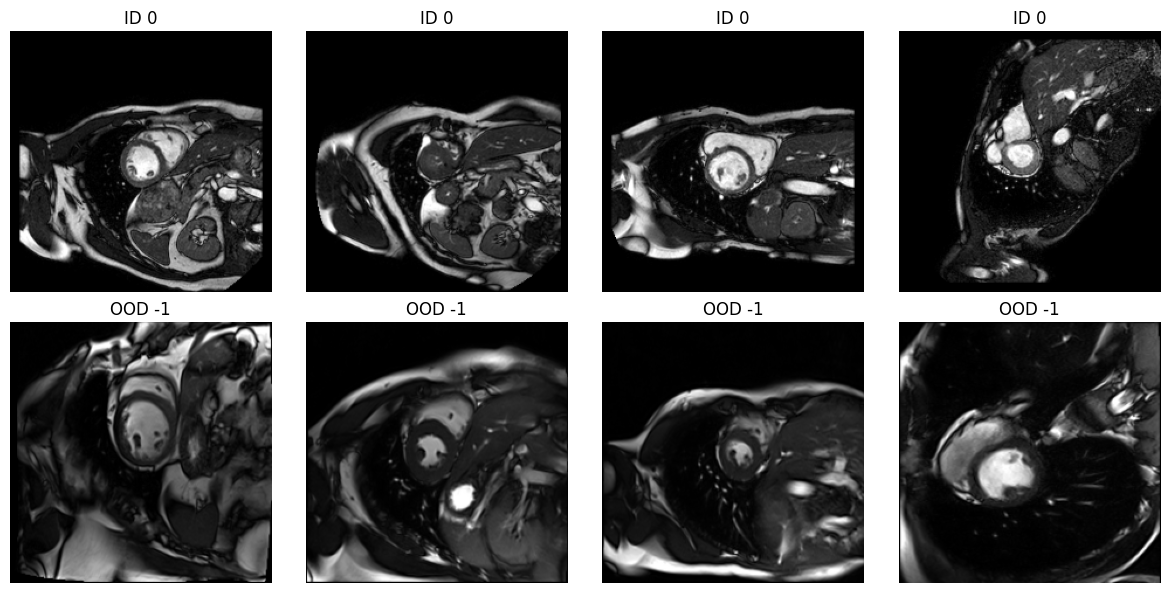

In [10]:
id_batch = next(iter(id_train_loader))
ood_batch = next(iter(ood_loader))

imgs = volume_middle_slice_for_display(id_batch["image"])
labels = id_batch["label"]
imgs_ood = volume_middle_slice_for_display(ood_batch["image"])
labels_ood = ood_batch["label"]

fig, axes = plt.subplots(2, 1, figsize=(6, 8))

axes[0].imshow(imgs[0], cmap="gray")
axes[0].set_title(f"ID volume, middle slice, label={int(labels[0])}")
axes[0].axis("off")

axes[1].imshow(imgs_ood[0], cmap="gray")
axes[1].set_title(f"OOD volume, middle slice, label={int(labels_ood[0])}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [11]:
# Stage 1: extract SAM-Med3D embeddings from the ID data and fit Mahalanobis

feats_list = []
labels_list = []

sam_med3d.eval()
with torch.no_grad():
    for batch in id_train_loader:
        imgs = batch["image"].to(device)
        y = batch["label"].to(device)

        z = get_embedding(imgs)   # [B, 384] global pooled 3D image-encoder features
        feats_list.append(z)
        labels_list.append(y)

Z_id = torch.cat(feats_list, dim=0)
Y_id = torch.cat(labels_list, dim=0)

print("Z_id:", Z_id.shape)
print("Y_id:", Y_id.shape, "unique labels:", torch.unique(Y_id))

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)


Z_id: torch.Size([525, 768])
Y_id: torch.Size([525]) unique labels: 

No device given. Will use 'cpu'.


tensor([0])


In [12]:
# Predict on ID validation and OOD datasets with SAM-Med3D features

feats_list_id_val = []
feats_list_ood = []

with torch.no_grad():
    for batch in id_val_loader:
        imgs = batch["image"].to(device)
        z = get_embedding(imgs)
        feats_list_id_val.append(z)

    for batch in ood_loader:
        imgs = batch["image"].to(device)
        z = get_embedding(imgs)
        feats_list_ood.append(z)

Z_id_val = torch.cat(feats_list_id_val, dim=0)
Z_ood = torch.cat(feats_list_ood, dim=0)

scores_id_val = detector.predict_features(Z_id_val)
scores_ood = detector.predict_features(Z_ood)

print("Z_ood:", Z_ood.shape)
print("scores_id:", scores_id_val.shape)
print("scores_ood:", scores_ood.shape)


Z_ood: torch.Size([570, 768])
scores_id: torch.Size([225])
scores_ood: torch.Size([570])


In [13]:
# Evaluate OOD metrics

img_scores = torch.cat([scores_id_val, scores_ood], dim=0)
img_labels = torch.cat([
    torch.zeros(len(scores_id_val), dtype=torch.long),
    -torch.ones(len(scores_ood), dtype=torch.long),
], dim=0)

metrics = OODMetrics()
metrics.update(img_scores, img_labels)
img_result = metrics.compute()

print("Image-level metrics:")
print(img_result)


Image-level metrics:
{'AUROC': 0.5123392343521118, 'AUTC': 0.502701997756958, 'AUPR-IN': 0.4821739196777344, 'AUPR-OUT': 0.7905192971229553, 'FPR95TPR': 1.0}


In [14]:
print("ID stats:")
print("mean:", scores_id_val.mean().item())
print("std:", scores_id_val.std().item())
print("min:", scores_id_val.min().item())
print("max:", scores_id_val.max().item())


ID stats:
mean: 564.3110961914062
std: 818347.25
min: -3377104.75
max: 6707483.5


In [15]:
print("OOD stats:")
print("mean:", scores_ood.mean().item())
print("std:", scores_ood.std().item())
print("min:", scores_ood.min().item())
print("max:", scores_ood.max().item())
print("median:", scores_ood.median().item())


OOD stats:
mean: -136714.140625
std: 1883911.375
min: -13679274.0
max: 11792428.0
median: -23375.921875


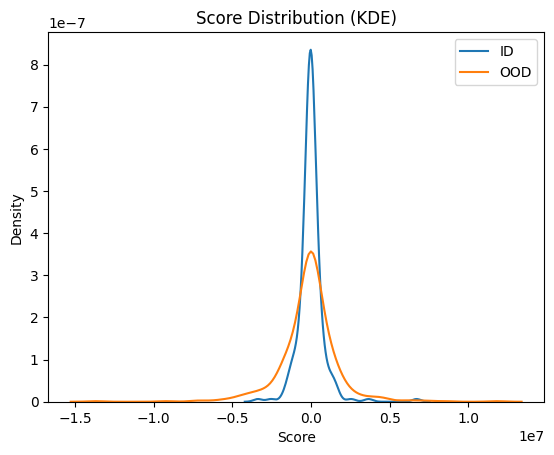

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

scores_id_np = scores_id_val.detach().cpu().numpy()
scores_ood_np = scores_ood.detach().cpu().numpy()

sns.kdeplot(scores_id_np, label="ID", fill=False)
sns.kdeplot(scores_ood_np, label="OOD", fill=False)

plt.title("Score Distribution (KDE)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()


In [ ]:
plt.hist(scores_ood.detach().cpu().numpy(), bins=200)
plt.title("OOD score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()
